In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.insert(1, '../')
import pyFBS

%load_ext autoreload
%autoreload 2

### Path of imported files

In [2]:
stl = r"../data/lab_testbench/STL/AB.stl"
xlsx = r"../data/lab_testbench/Measurements/AM_Measurements.xlsx"

full_file = r'../data/lab_testbench/FEM/AB/file.full'
ress_file = r'../data/lab_testbench/FEM/AB/file.rst'

### Eigenvalues and eigenvectors of system

In [3]:
MK = pyFBS.MK_model(ress_file,full_file,no_modes = 100,recalculate = False)

### Show 3D model

In [4]:
view3D = pyFBS.display.view3D(show_origin= True)
view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = 1)

##### Import and show impact locations

In [5]:
df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')
view3D.show_imp(df_imp)
# view3D.label_imp(df_imp)
# df_imp

##### Import and show response locations

In [6]:
df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
view3D.show_chn(df_chn)
# view3D.label_chn(df_chn)
# df_chn

##### Updated locations of responses and impacts to where nodes actually exist

In [7]:
df_chn_up = MK.update_locations_df(df_chn)
df_imp_up = MK.update_locations_df(df_imp)

# view3D.show_imp(df_imp_up, color = "k")

### FRFs generation

In [8]:
MK.FRF_synth(df_chn,df_imp, 
             f_start=0,
             f_end=2002.5,
             f_resolution=2.5,
             modal_damping = 0.003,
             frf_type = "accelerance")

### Experimental data import

In [9]:
freq, Y_AB_exp = np.load(r"../data/lab_testbench/Measurements/Y_AB.p",allow_pickle = True)

### FRF comparison

,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
5,Sensor 2,AM_AB_final,Translation,Acceleration,m/s^2,AM_AB_final,2,100,-0.041679,0.278838,0.0221,0.0,0.0,1.0,NaN


,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
5,Impact 6,AM_AB_final,6,100,Force,N,0.015171,0.048171,0.017,0.0,0.0,-1.0


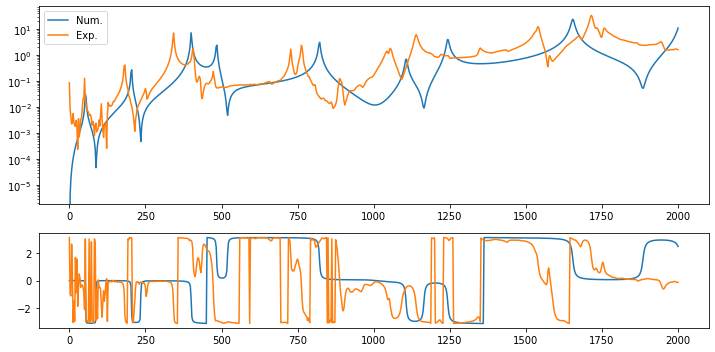

In [10]:
plt.figure(figsize = (12,8))

s1 = 5
s2 = 5

display(df_chn.iloc[[s1]])
display(df_imp.iloc[[s2]])

plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[:,s1,s2]), label = "Num.")
plt.semilogy(freq,np.abs(Y_AB_exp[s1,s2]), label = "Exp.")
plt.legend()

plt.subplot(413)
plt.plot(MK.freq,np.angle(MK.FRF[:,s1,s2]))
plt.plot(freq,np.angle(Y_AB_exp[s1,s2]))


# SEMM

In [11]:
H_exp = np.transpose(Y_AB_exp[0:15, 5:20, :], (2, 0, 1))
new_frf_new = pyFBS.newSEMM(MK.FRF[:], H_exp[:], 
                            df_chn_num = df_chn, 
                            df_imp_num = df_imp, 
                            df_chn_exp = df_chn[0:15], 
                            df_imp_exp = df_imp[5:20], 
                            SEMM_type='fully-extended-svd', red_comp=10, red_eq=10)

,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
24,Sensor 9,AM_AB_final,Translation,Acceleration,m/s^2,AM_AB_final,9,10,0.315197,0.207024,0.020318,0.0,0.0,1.0,NaN


,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
24,Impact 25,AM_AB_final,25,10,Force,N,0.306718,0.255035,0.027,0.0,0.0,-1.0


Text(0, 0.5, 'Angle [rad]')

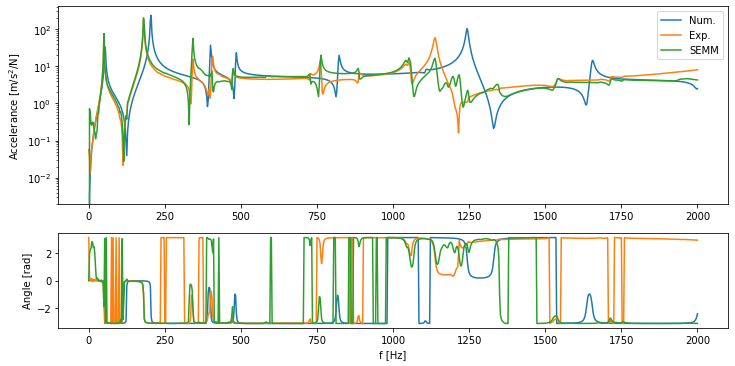

In [12]:
s1 = 24
s2 = 24

display(df_chn.iloc[[s1]])
display(df_imp.iloc[[s2]])

plt.figure(figsize = (12,8))

plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[:,s1,s2]), label = "Num.")
plt.semilogy(freq,np.abs(Y_AB_exp[s1,s2]), label = "Exp.")
plt.semilogy(freq,np.abs(new_frf_new[:, s1,s2]), label = "SEMM")
plt.ylabel("Accelerance [m/s$^2$/N]")
plt.legend()

plt.subplot(413)
plt.plot(MK.freq,np.angle(MK.FRF[:,s1,s2]))
plt.plot(freq,np.angle(Y_AB_exp[s1,s2]))
plt.plot(MK.freq,np.angle(new_frf_new[:,s1,s2]))
plt.xlabel("f [Hz]")
plt.ylabel("Angle [rad]")